In [12]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import quad
from scipy.interpolate import RectBivariateSpline, PchipInterpolator
from functools import lru_cache
# Hiding deprecated warning
import warnings
warnings.filterwarnings("ignore", category=DeprecationWarning)
# Setting numpy print options for better readability
np.set_printoptions(precision=3, suppress=True, linewidth=300)

#region Setting fonts and sizes for plots
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['DejaVu Serif']
SMALL_SIZE = 14
MEDIUM_SIZE = 16
LARGE_SIZE = 18

plt.rc('font', size=SMALL_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=MEDIUM_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=MEDIUM_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=LARGE_SIZE)  # fontsize of the figure title
plt.rcParams["axes.formatter.limits"] = (-99, 99)
#endregion

#region Physical parameters in original units
c = 3e8                     # speed of light in m/s
hbar = 6.58e-16             # reduced Planck's constant in eV·s
k_B = 8.617333262e-5        # Boltzmann constant in eV/K

# Masses, PhysRevB.44 Values
m_rest = 5.68e-12           # rest mass electron in eV·s^2·m^-2
m_e = 3.81e-13              # electron mass in eV·s^2·m^-2
m_h = 2.56e-12              # hole mass in eV·s^2·m^-2

M_eff = 7.8e-5 * m_rest     # effective polariton mass in eV·s^2·m^-2  (PRB 77 155317)

E_bind = 4.2e-3             # exciton binding energy in eV
E_gap = 1.6 + E_bind        # GaAs band gap energy in eV

# Polariton parameters
T_polariton = 20            # temperature in K
Omega = 1.4e-2              # Rabi splitting in eV, don't need to rescale as not used for exciton calc
concentration = 0.3e12        # exciton concentration in m^-2
beta = 1 / (k_B * T_polariton)  # inverse temperature in eV^-1

D_0 = 2.26e-20              # disorder strength in eV^2·m^2
disorder = np.round(np.linspace(0.0, 2.0, 11), 9)  # range of η values
k_max = 4e6                 # Dispersion relation range in m^-1 from Snoke 2023
g_ex = 12e-18               # exciton-exciton interaction strength in eV·m^2 from Snoke 2023

# Compute the exciton radius (length scale)
a = hbar / np.sqrt(2 * (m_e * m_h / (m_e + m_h)) * E_bind)   # in metres

# ------------------------------------------------------------
# Define conversion factors for natural units:
# 1. Set energy scale so that E_bind becomes 1.
E_unit = E_bind           # new energy unit: 1 (in units of E_bind)

# 2. Set length scale so that exciton radius a becomes 1.
L_unit = a                # new length unit: 1 (in units of a)
# ------------------------------------------------------------
# Rescale parameters using the conversion factors:

# Speed of light (has dimensions length/time)
c = c  / L_unit
# Energies (divide by E_unit)
hbar = hbar / E_unit
k_B = k_B / E_unit
E_gap = E_gap / E_unit
E_bind = E_bind / E_unit      # by construction, equals 1

# Lengths (divide by L_unit)
a = a / L_unit               # rescaled exciton radius

# Masses:
# In our units, mass m has dimensions [energy]^1 [length]^-2 [time]^2.
m_e = m_e * L_unit**2 / E_unit 
m_h = m_h * L_unit**2 / E_unit 
m_rest = m_rest * L_unit**2 / E_unit
M_eff = M_eff * L_unit**2 / E_unit

# Disorder strength D_0 has dimensions eV^2·m^2, so:
D_0 = D_0 / (E_unit**2 * L_unit**2)

# Dispersion relation range (divide by L_unit^-1)
k_max = k_max * L_unit

M = (m_e + m_h)    # total mass of the exciton
#endregion

# # Converting band structure constants to correct units
m_prime = 10
alpha_e = m_prime * m_rest / m_e
alpha_h = m_prime * m_rest / m_h


# Printing band structure constants
print(f"alpha_e = {alpha_e}, alpha_h = {alpha_h}")



alpha_e = 149.0813648293963, alpha_h = 22.1875


In [13]:
# Setting up numerical integration using iterative method

def F(q, Q, eta=1.0):
    return -eta*q/(E_gap - E_bind - (hbar**2 * q**2)/(2*M) + Q + 1e-9j)  # changed epsilon

@lru_cache(maxsize=None)
def term3(q, k):
    def integrand(theta):
        return (-1/np.pi * m_e**2 * m_h**2) * (k**2 + q**2 -2*k*q*np.cos(theta) + 4*M**2/(a**2 * m_e**2))**(-3/2) * (k**2 + q**2 -2*k*q*np.cos(theta) + 4*M**2/(a**2 * m_h**2))**(-3/2)
    val, err = quad(integrand, 0, 2*np.pi)
    return val

prefactor = (4 * D_0 * M**6 * m_prime**2 * m_rest**2)/(np.pi* a**6 * m_e**2 * m_h**2)
def K(q, k):
    t1 = ((k**2 + q**2 + 4 * M**2/(a**2 * m_e**2))**2 + 2*k**2 * q**2) /(m_e**4 * 
            ((k**2 + q**2 + 4*M**2/(a**2 * m_e**2))**2 -4*k**2*q**2)**(5/2))
    t2 = ((k**2 + q**2 + 4 * M**2/(a**2 * m_h**2))**2 + 2*k**2 * q**2) /(m_h**4 * 
            ((k**2 + q**2 + 4*M**2/(a**2 * m_h**2))**2 -4*k**2*q**2)**(5/2))
    t3 = term3(q, k)
    return prefactor*(t1 + t2 + t3)



Completed coarse kernel evaluation on non-uniform segmented grid.
Coarse grid: N=2000  →  N_A=500, N_B=200, N_C=1100, N_D=200
Picard grid: N=10000  →  N_A=2500, N_B=1000, N_C=5500, N_D=1000
Boundaries (m⁻¹): 0 | 1.0e+08 | 2.0e+09 | 8.0e+09 | 1.2e+10
Coarse grid: N=2000  →  N_A=500, N_B=200, N_C=1100, N_D=200
Picard grid: N=10000  →  N_A=2500, N_B=1000, N_C=5500, N_D=1000
Boundaries (m⁻¹): 0 | 1.0e+08 | 2.0e+09 | 8.0e+09 | 1.2e+10


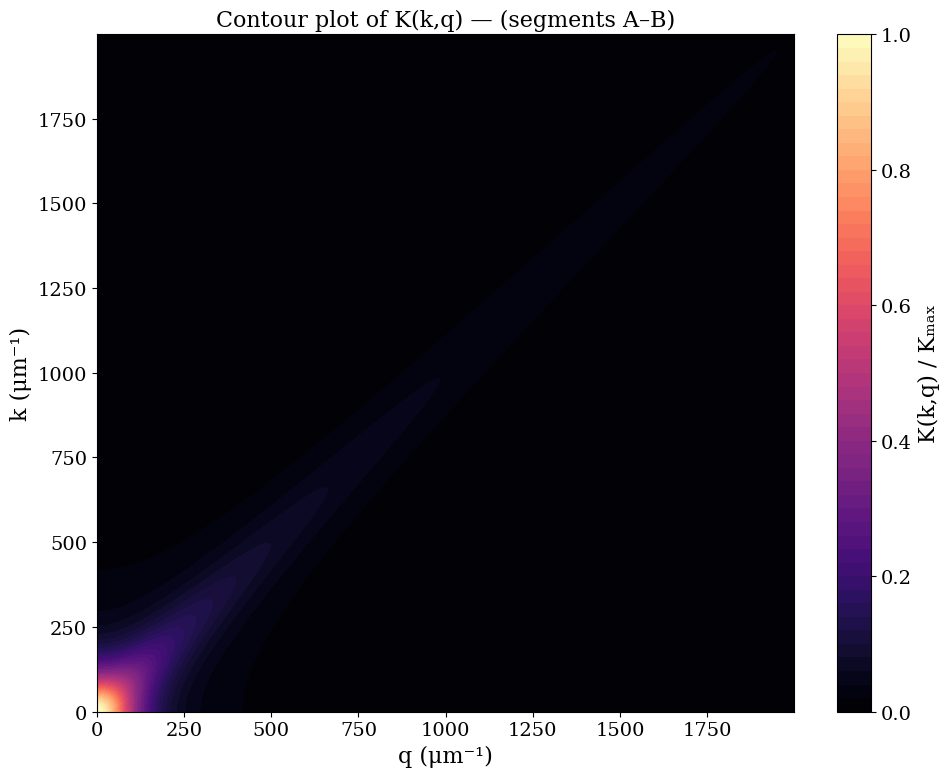

In [ ]:
# Pre-compute on a coarse non-uniform grid, then interpolate to the finer non-uniform Picard grid

# Extend domain to include tail segment D (up to ~1.2e10 m^-1 in SI)
k_domain_max = 1.2e10 * L_unit

# Resonant peak near q ~ 4.7e9 m^-1; convert SI boundaries to natural units.
q_A_end = 1e8  * L_unit   # Segment A/B boundary  (m^-1 → natural units)
q_B_end = 2e9  * L_unit   # Segment B/C boundary
q_C_end = 8e9  * L_unit   # Segment C/D boundary

def build_segmented_grid(total_points, q_A_end, q_B_end, q_C_end, q_max,
                         frac_A=0.25, frac_B=0.10, frac_C=0.55, frac_D=0.10,
                         power_A=2.0):
    """Build a monotone 4-segment non-uniform grid:
       A: power-law clustered near 0
       B: coarse linear
       C: dense linear around resonance
       D: sparse log tail
    """
    assert abs(frac_A + frac_B + frac_C + frac_D - 1.0) < 1e-12, "Fractions must sum to 1"
    if not (0 < q_A_end < q_B_end < q_C_end < q_max):
        raise ValueError("Require 0 < q_A_end < q_B_end < q_C_end < q_max")

    N_A = max(2, round(frac_A * total_points))
    N_B = max(2, round(frac_B * total_points))
    N_C = max(2, round(frac_C * total_points))
    N_D = max(2, total_points - N_A - N_B - N_C)  # absorb rounding remainder

    # Segment A: IR power-law spacing [0, q_A_end]
    t_A = np.linspace(0.0, 1.0, N_A)
    q_A = q_A_end * t_A**power_A

    # Segment B: coarse linear [q_A_end, q_B_end]
    q_B = np.linspace(q_A_end, q_B_end, N_B + 1)[1:]   # exclude shared endpoint

    # Segment C: dense linear [q_B_end, q_C_end]
    q_C = np.linspace(q_B_end, q_C_end, N_C + 1)[1:]   # exclude shared endpoint

    # Segment D: sparse log-spaced tail [q_C_end, q_max]
    q_D = np.geomspace(q_C_end, q_max, N_D + 1)[1:]    # exclude shared endpoint

    grid = np.concatenate([q_A, q_B, q_C, q_D])
    return grid, {"N_A": N_A, "N_B": N_B, "N_C": N_C, "N_D": N_D}

# --- Grid size controls ------------------------------------------------------
N_coarse = 2_000
N_total  = 10_000   # Total number of Picard quadrature points

# Same segment fractions for both coarse and Picard grids
frac_A = 0.25       # IR power-law  [0,          q_A_end]
frac_B = 0.10       # Middle linear [q_A_end,    q_B_end]
frac_C = 0.55       # Resonance     [q_B_end,    q_C_end]  ← most points here
frac_D = 0.10       # Log tail      [q_C_end,    k_domain_max]
# -----------------------------------------------------------------------------

# Coarse non-uniform grid for actual kernel evaluation
q_coarse, coarse_counts = build_segmented_grid(
    N_coarse, q_A_end, q_B_end, q_C_end, k_domain_max,
    frac_A=frac_A, frac_B=frac_B, frac_C=frac_C, frac_D=frac_D, power_A=2.0
)
k_coarse = q_coarse.copy()

integrand_mesh_coarse = np.zeros((len(q_coarse), len(k_coarse)), dtype=np.float64)
for k_idx, k_val in enumerate(k_coarse):
    for q_idx, q_val in enumerate(q_coarse):
        integrand_mesh_coarse[q_idx, k_idx] = K(q_val, k_val)

print("Completed coarse kernel evaluation on non-uniform segmented grid.")

# Finer non-uniform grid for Picard iteration
q_picard, picard_counts = build_segmented_grid(
    N_total, q_A_end, q_B_end, q_C_end, k_domain_max,
    frac_A=frac_A, frac_B=frac_B, frac_C=frac_C, frac_D=frac_D, power_A=2.0
)
k_picard = q_picard.copy()
N_picard = len(q_picard)

# Interpolate coarse kernel onto the finer non-uniform Picard grid
kernel_interp  = RectBivariateSpline(q_coarse, k_coarse, integrand_mesh_coarse)
integrand_mesh = kernel_interp(q_picard, k_picard)

# Save and reload exactly what Picard will use
np.save('Integrand Meshes/integrand_mesh.npy', integrand_mesh)
# integrand_mesh = np.load('Integrand Meshes/integrand_mesh.npy')

# Keep explicit Picard aliases
q = q_picard
k = k_picard
N = N_picard

# Trapezoid quadrature weights for non-uniform grid
weights        = np.empty(N_picard)
weights[0]     = (q_picard[1]  - q_picard[0])  / 2
weights[-1]    = (q_picard[-1] - q_picard[-2]) / 2
weights[1:-1]  = (q_picard[2:] - q_picard[:-2]) / 2

print(f"Coarse grid: N={len(q_coarse)}  →  "
      f"N_A={coarse_counts['N_A']}, N_B={coarse_counts['N_B']}, "
      f"N_C={coarse_counts['N_C']}, N_D={coarse_counts['N_D']}")
print(f"Picard grid: N={N_picard}  →  "
      f"N_A={picard_counts['N_A']}, N_B={picard_counts['N_B']}, "
      f"N_C={picard_counts['N_C']}, N_D={picard_counts['N_D']}")
print(f"Boundaries (m⁻¹): 0 | {q_A_end/L_unit:.1e} | {q_B_end/L_unit:.1e} | "
      f"{q_C_end/L_unit:.1e} | {k_domain_max/L_unit:.1e}")

# Picard iteration using trapezoid quadrature weights
def picard_iteration(Q_init, q, K_matrix, weights, eta=1.0, tol=1e-5, max_iter=5000, w=1.0, verbose=True):
    """
    Vectorized Picard iteration with non-uniform trapezoid quadrature.
    Q_init  : 1D complex array, initial guess on the Picard grid.
    q       : 1D array, quadrature nodes.
    K_matrix: 2D array, kernel evaluated on (q, k) grid.
    weights : 1D array, trapezoid quadrature weights matching q.
    """
    delta_k = np.zeros(max_iter, dtype=complex)
    for iteration in range(max_iter):
        F_vec = F(q, Q_init, eta=eta) * weights
        Q_new = (1 - w) * Q_init + w * np.sum(K_matrix * F_vec[:, None], axis=0)

        diff = np.linalg.norm(Q_new - Q_init)
        delta_k[iteration] = diff
        if verbose and iteration % 100 == 0:
            print(f'Iteration {iteration+1}, diff = {diff}')
        if diff < tol:
            Q_init = Q_new
            break
        Q_init = Q_new

    return Q_init, delta_k

# Plot kernel over k=0 regions A
n_plot = np.searchsorted(q_picard, q_A_end)
q_mesh_plot, k_mesh_plot = np.meshgrid(q_picard[:n_plot], k_picard[:n_plot])

K_window = np.asarray(integrand_mesh[:n_plot, :n_plot])
K_norm   = K_window / K_window.max()

fig = plt.figure(figsize=(10, 8))
contour = plt.contourf(
    (1e-6) * q_mesh_plot / L_unit,
    (1e-6) * k_mesh_plot / L_unit,
    K_norm,
    levels=np.linspace(0, 1, 51),
    cmap='magma'
)
cbar = plt.colorbar(contour, label='K(k,q) / Kₘₐₓ', ticks=[0.0, 0.2, 0.4, 0.6, 0.8, 1.0])
cbar.ax.set_yticklabels(['0.0', '0.2', '0.4', '0.6', '0.8', '1.0'])
plt.xlabel('q (μm⁻¹)')
plt.ylabel('k (μm⁻¹)')
plt.title('Contour plot of K(k,q) — (segment A)')
plt.tight_layout()
plt.show()


In [15]:
# Running the Picard iteration for different eta factors

eta_grid = np.round(np.linspace(0.0, 2.0, 21), 9)  # range of η values
integrand_mesh = np.load('Integrand Meshes/integrand_mesh.npy')
N_picard = len(q_picard)

Q_results = np.zeros((len(eta_grid), N_picard), dtype=complex)
delta_k_results = np.zeros((len(eta_grid), 5000), dtype=complex)
Q_init = (1+1j)*np.ones(N_picard, dtype=complex)  # Constant starting point in the complex plane

for i, eta in enumerate(eta_grid):
    print(f'Running Picard iteration for eta = {eta}, index = {i}/{len(eta_grid)}')
    res = picard_iteration(Q_init, q_picard, K_matrix=integrand_mesh, weights=weights, eta=eta, tol=1e-6, w=0.99, verbose=True)
    Q_results[i] = np.copy(res[0])
    delta_k_results[i] = np.copy(res[1])
    Q_init = np.copy(res[0])  # Update the initial guess for the next iteration

# Saving the Q(k) results to a numpy file
np.save('Q_results/Q_results.npy', Q_results)


Running Picard iteration for eta = 0.0, index = 0/21
Iteration 1, diff = 140.00714267494052
Iteration 1, diff = 140.00714267494052
Running Picard iteration for eta = 0.1, index = 1/21
Running Picard iteration for eta = 0.1, index = 1/21
Iteration 1, diff = 606.3046366805497
Iteration 1, diff = 606.3046366805497
Running Picard iteration for eta = 0.2, index = 2/21
Running Picard iteration for eta = 0.2, index = 2/21
Iteration 1, diff = 666.1907690972307
Iteration 1, diff = 666.1907690972307
Running Picard iteration for eta = 0.3, index = 3/21
Running Picard iteration for eta = 0.3, index = 3/21
Iteration 1, diff = 613.5449932580981
Iteration 1, diff = 613.5449932580981
Running Picard iteration for eta = 0.4, index = 4/21
Running Picard iteration for eta = 0.4, index = 4/21
Iteration 1, diff = 581.8391726698007
Iteration 1, diff = 581.8391726698007
Running Picard iteration for eta = 0.5, index = 5/21
Running Picard iteration for eta = 0.5, index = 5/21
Iteration 1, diff = 559.20435219274

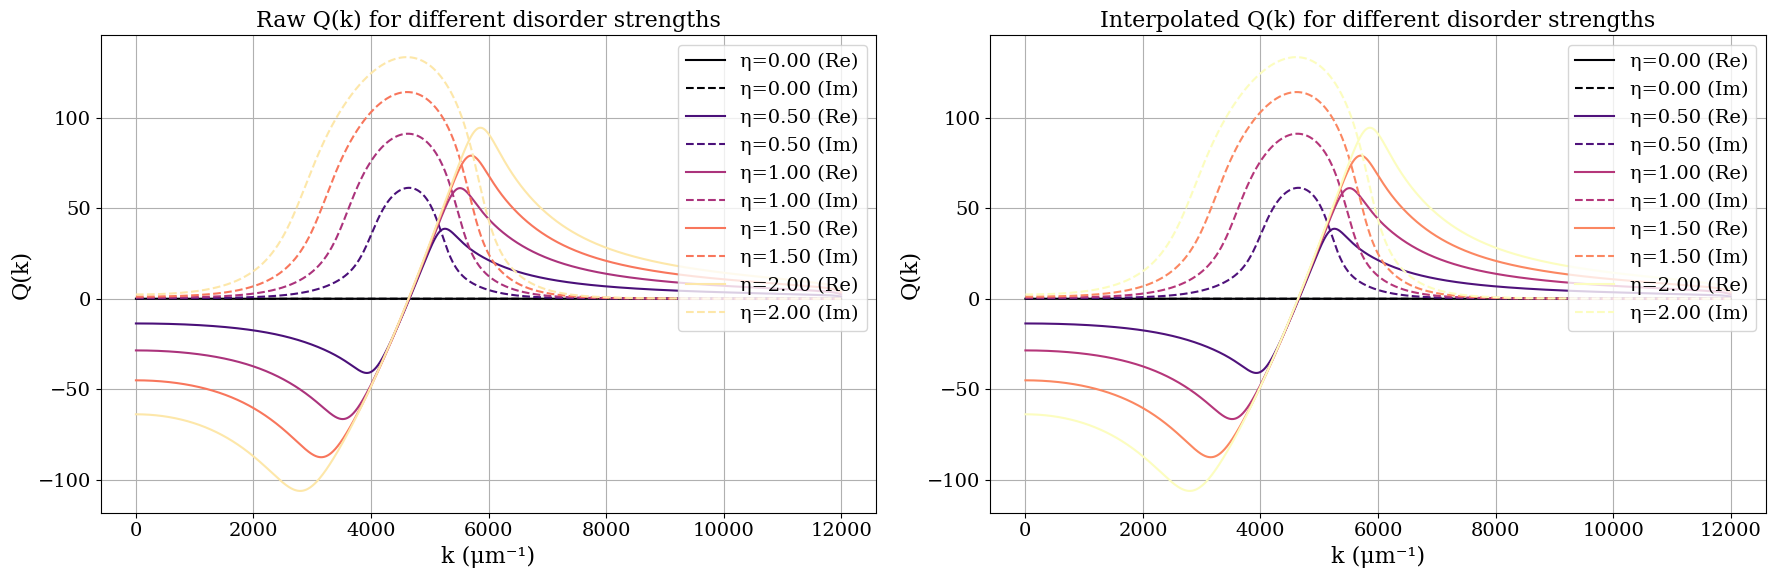

In [16]:
# Q(k) diagnostic plots: raw and interpolated side by side
Q_results = np.load('Q_results/Q_results.npy')

Q_interp_real = RectBivariateSpline(q_picard, eta_grid, np.real(Q_results).T)
Q_interp_imag = RectBivariateSpline(q_picard, eta_grid, np.imag(Q_results).T)

plot_indices = [0, 5, 10, 15, 20]
etas_interp = [0.0, 0.5, 1.0, 1.5, 2.0]

fig, axs = plt.subplots(1, 2, figsize=(18, 6))

# Left: raw Q_results
for idx in plot_indices:
    axs[0].plot(q_picard * 1e-6 / L_unit, Q_results[idx].real, label=f'η={eta_grid[idx]:.2f} (Re)', color=plt.cm.magma(idx / len(eta_grid)))
    axs[0].plot(q_picard * 1e-6 / L_unit, Q_results[idx].imag, label=f'η={eta_grid[idx]:.2f} (Im)', linestyle='--', color=plt.cm.magma(idx / len(eta_grid)))
axs[0].set_xlabel('k (μm⁻¹)')
axs[0].set_ylabel('Q(k)')
axs[0].set_title('Raw Q(k) for different disorder strengths')
axs[0].legend()
# axs[0].set_xlim(0, k_domain_max * 1e-6 / L_unit)
axs[0].grid()

# Right: interpolated Q
for eta in etas_interp:
    Q_real_interp = Q_interp_real(q_picard, eta)
    Q_imag_interp = Q_interp_imag(q_picard, eta)
    axs[1].plot(q_picard * 1e-6 / L_unit, Q_real_interp, label=f'η={eta:.2f} (Re)', color=plt.cm.magma(int(eta / 2.0 * 255)))
    axs[1].plot(q_picard * 1e-6 / L_unit, Q_imag_interp, label=f'η={eta:.2f} (Im)', linestyle='--', color=plt.cm.magma(int(eta / 2.0 * 255)))
axs[1].set_xlabel('k (μm⁻¹)')
axs[1].set_ylabel('Q(k)')
axs[1].set_title('Interpolated Q(k) for different disorder strengths')
axs[1].legend()
# axs[1].set_xlim(0, k_domain_max * 1e-6 / L_unit)
axs[1].grid()

plt.tight_layout()
plt.show()


In [ ]:
# Switching back to original units for dispersion relations
c = 3e8                     # speed of light in m/s
hbar = 6.58e-16             # reduced Planck's constant in eV·s
k_B = 8.617333262e-5        # Boltzmann constant in eV/K

# Masses, PhysRevB.44 Values
m_rest = 5.68e-12           # rest mass electron in eV·s^2·m^-2
m_e = 3.81e-13              # electron mass in eV·s^2·m^-2
m_h = 2.56e-12              # hole mass in eV·s^2·m^-2
M_eff = 7.8e-5 * m_rest     # effective polariton mass in eV·s^2·m^-2  (PRB 77 155317)
M = (m_e + m_h)             # total mass of the exciton

E_bind = 4.2e-3             # exciton binding energy in eV
E_gap = 1.6 + E_bind        # GaAs band gap energy in eV

# Input k in m^-1, eta dimensionless and output Q in eV
def Q(k, eta):
    """
    Scalar Q(k, eta). Returns a scalar even though interp2d gives a (1,1) array.
    """
    if eta == 0.0:
        return 0.0
    # Converting k from m^-1 to natural units
    k = k * L_unit
    val_r = Q_interp_real(k, eta)
    val_i = Q_interp_imag(k, eta)
    return E_unit * (val_r + 1j*val_i).item()  # total

# Vectorized wrapper: works for array k and/or array eta (broadcasted)
Qv = np.vectorize(Q, otypes=[complex])

def E_ex(k, eta):
    k = np.asarray(k, dtype=float)
    return E_gap - E_bind + (hbar**2) * k**2 / (2.0 * M) - Qv(k, eta)

def E_ph(k, eta):
    # now broadcasts over k and eta
    n = 3.0
    k = np.asarray(k, dtype=float)
    E_0 = np.real(E_ex(0.0, eta))
    return np.sqrt((hbar * c * k / n)**2 + E_0**2)

def E_LP(k, eta, disorder_tuned=True):
    # Outputs the lower polariton branch energy in eV
    k = np.asarray(k, dtype=float)
    if disorder_tuned:
        photon_energy  = E_ph(k, eta)  # Cavity tuned to disorder-dependent exciton energy
    else:
        photon_energy  = E_ph(k, 0)  # Cavity tuned to disorder-free exciton energy
    exciton_energy = E_ex(k, eta)
    return 0.5 * (photon_energy + exciton_energy
                  - np.sqrt((photon_energy - exciton_energy)**2 + 4.0 * Omega**2))


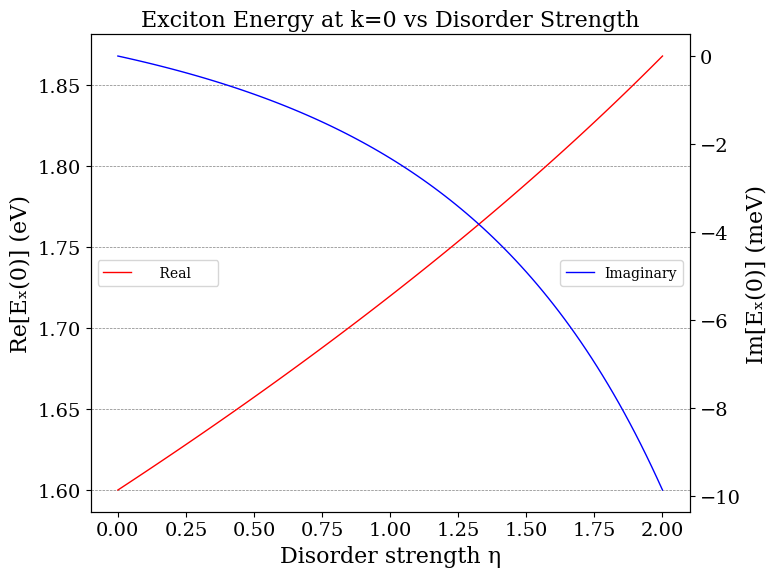

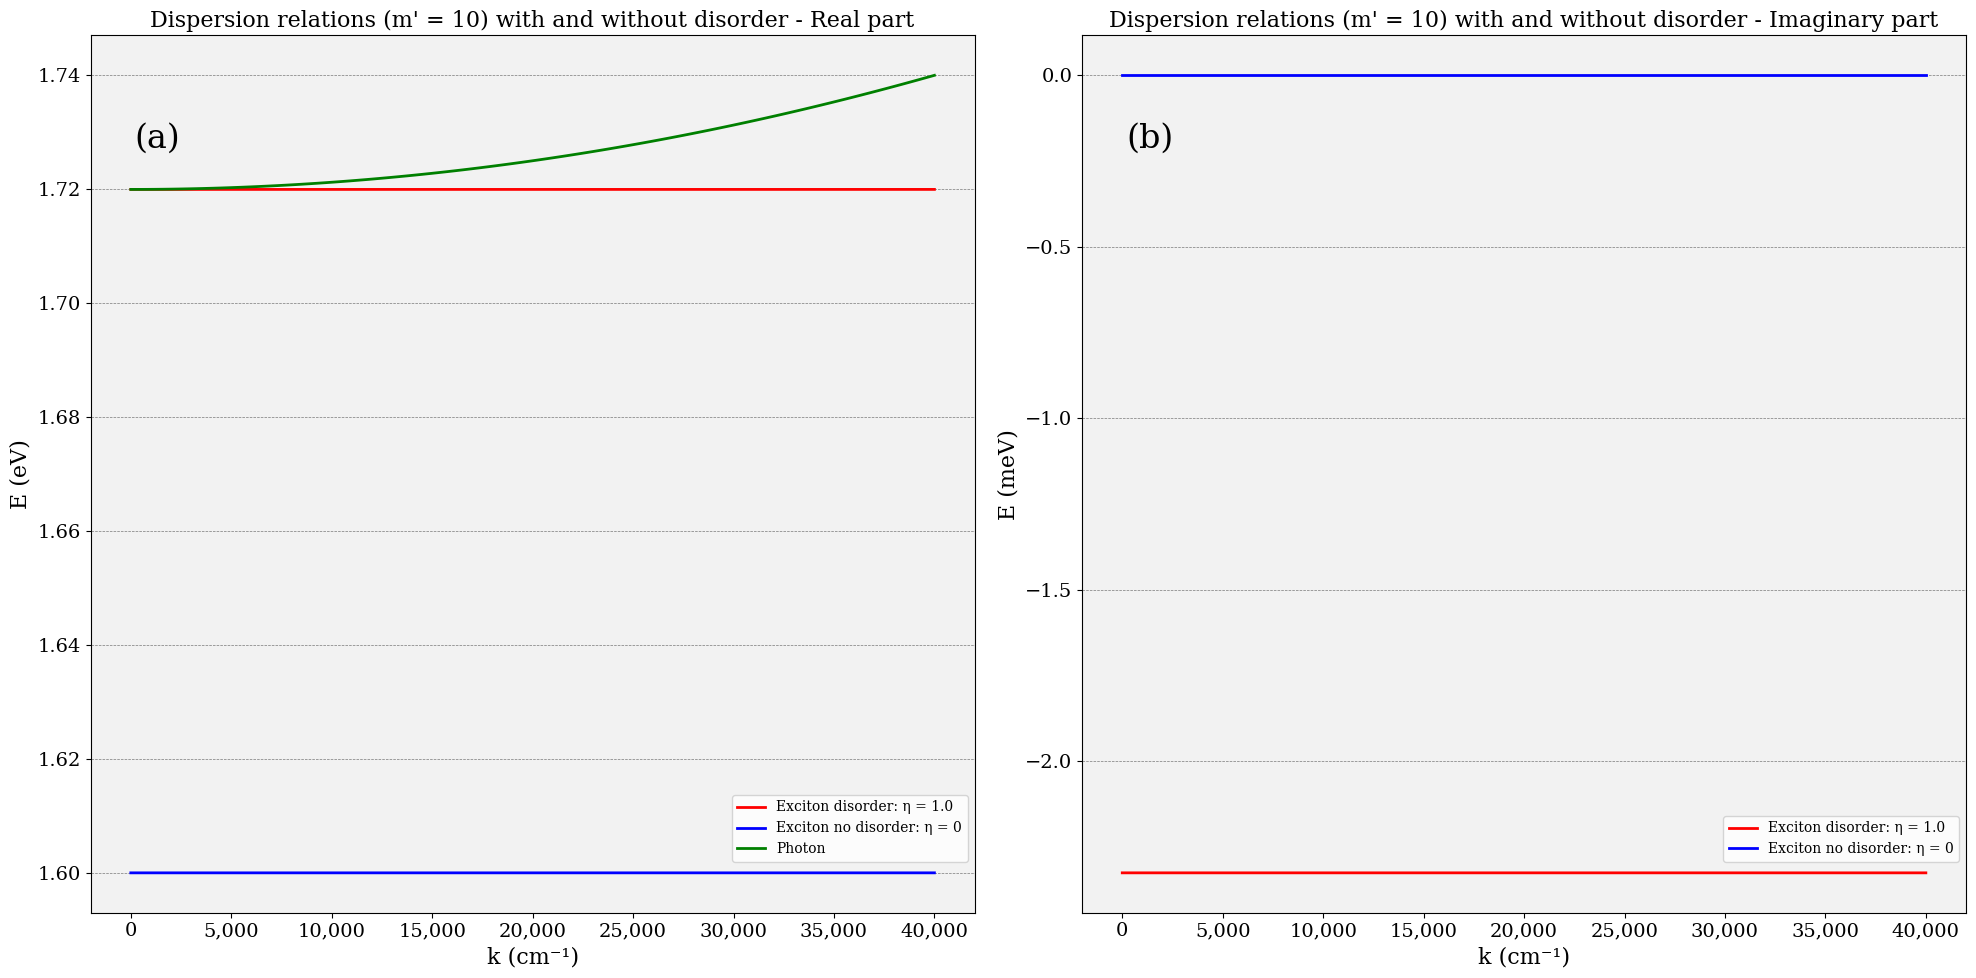

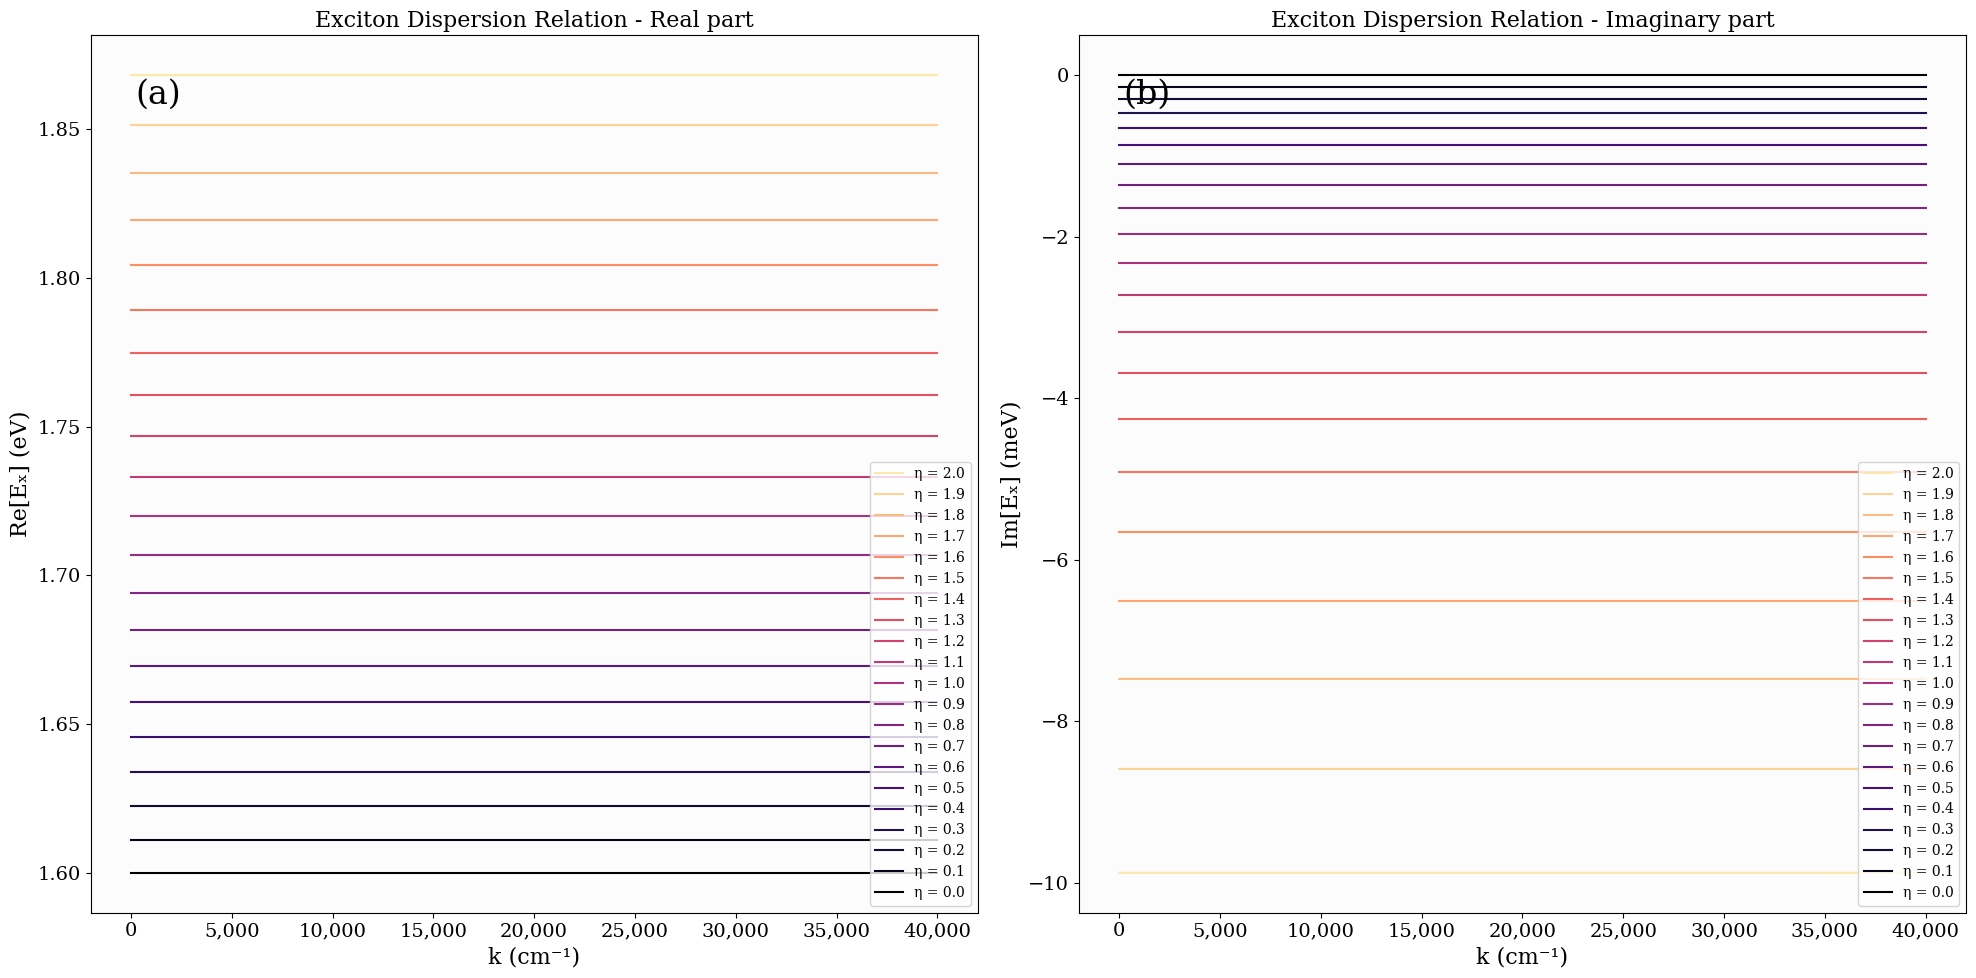

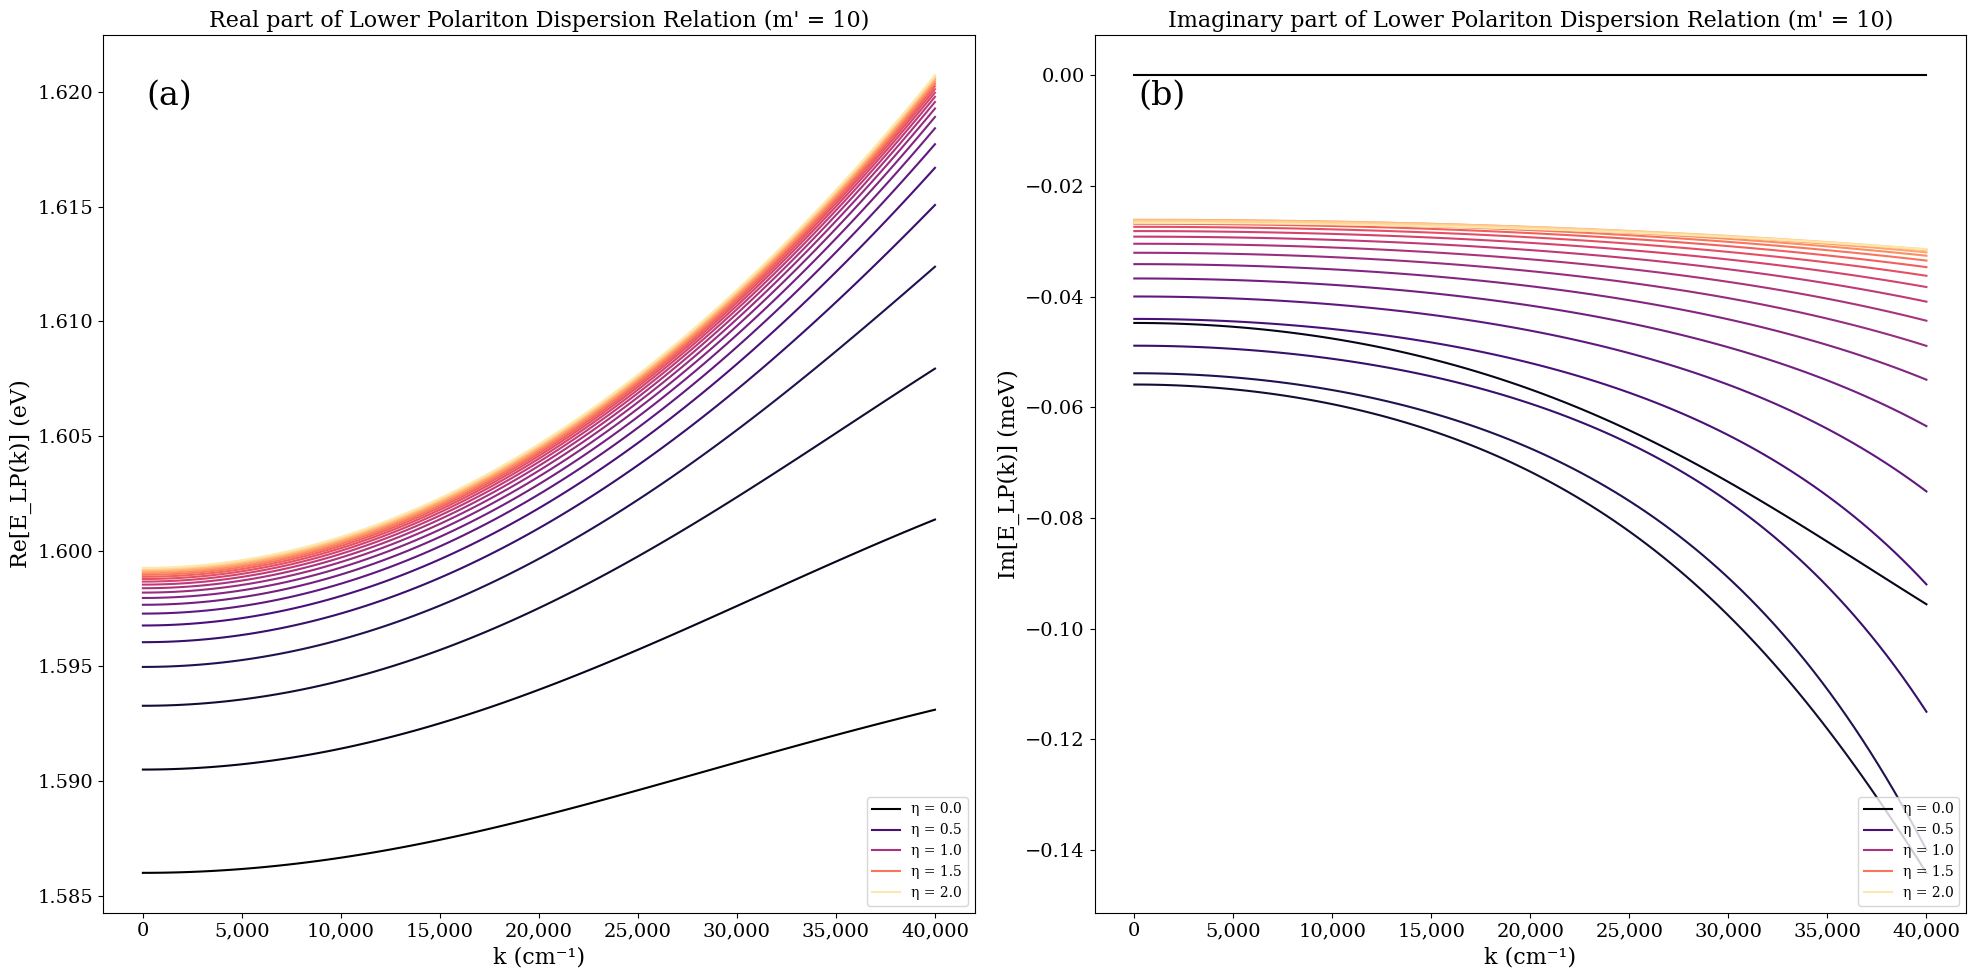

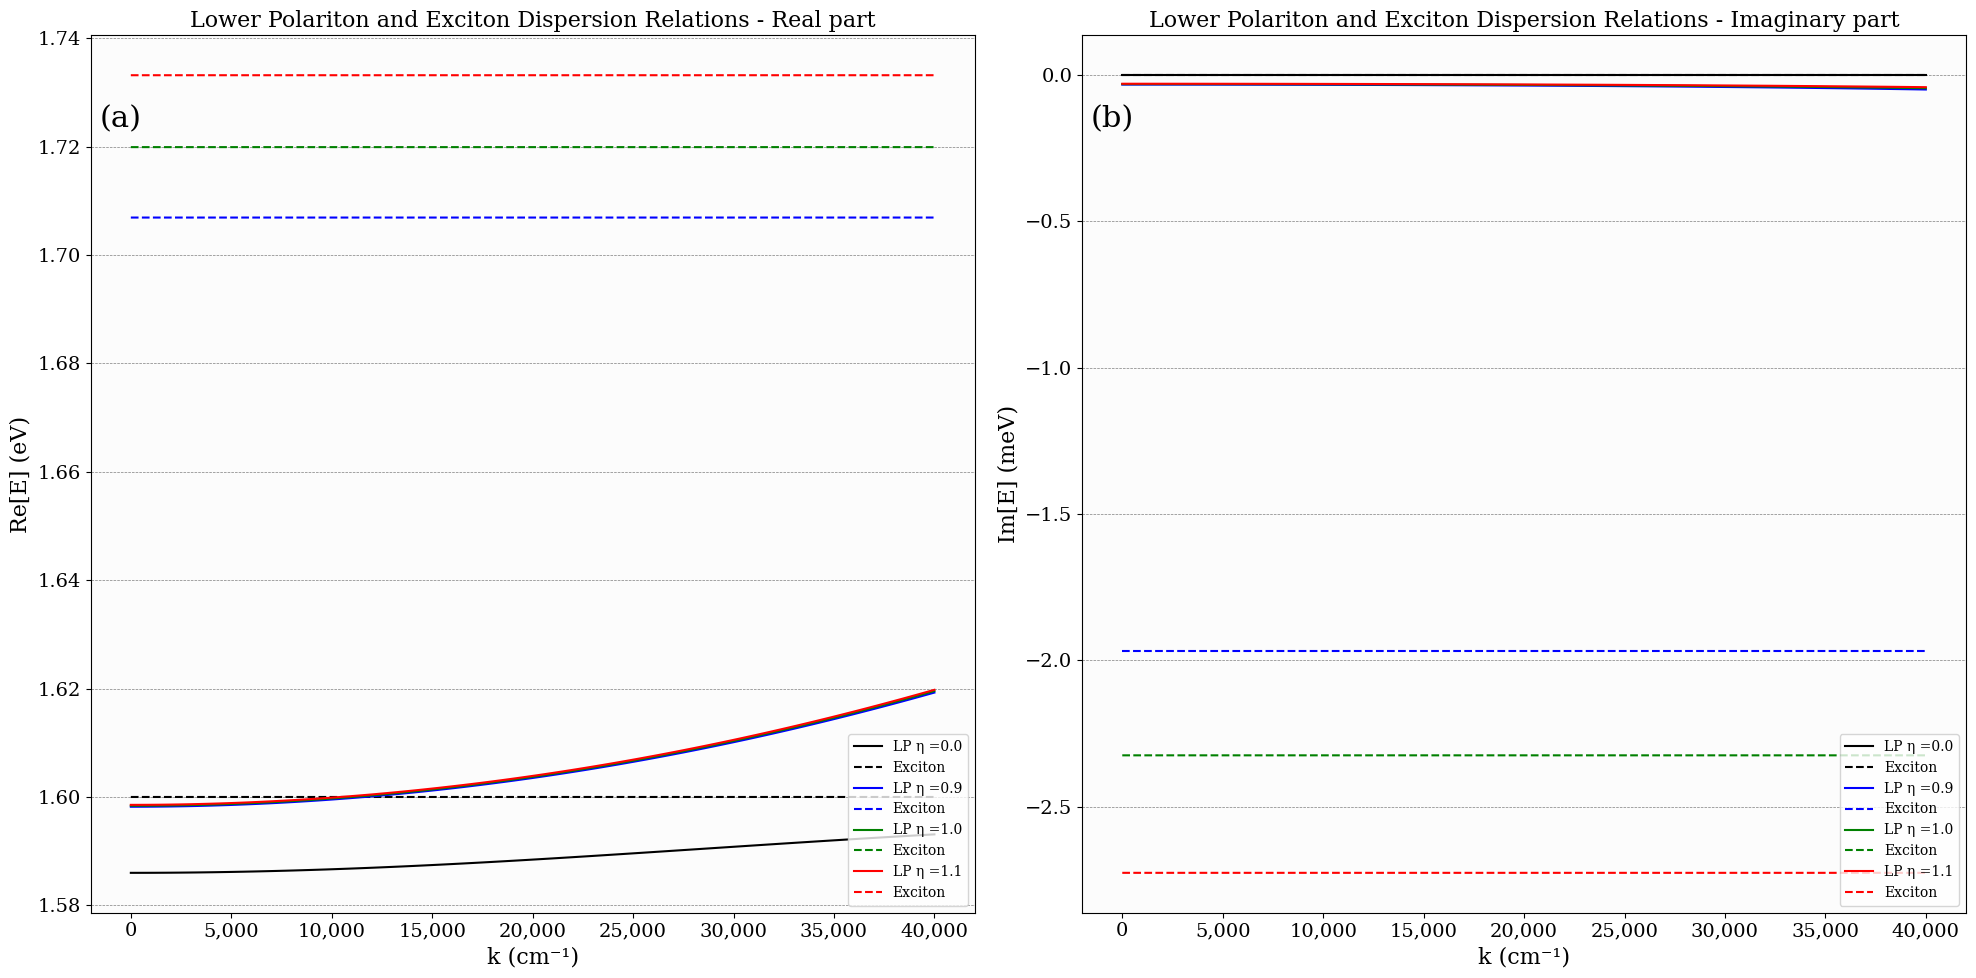

In [ ]:
# Post-processing: E_ex(k=0) vs disorder strength and dispersion plots
N_k_disp = 100
k_grid_disp = np.linspace(0, 4e6, N_k_disp)

# Pre-compute exciton and both LP variants for all eta
E_ex_results_disp    = np.zeros((len(eta_grid), N_k_disp), dtype=complex)
E_LP_results_tuned   = np.zeros((len(eta_grid), N_k_disp), dtype=complex)
E_LP_results_untuned = np.zeros((len(eta_grid), N_k_disp), dtype=complex)
for eta_idx, eta_val in enumerate(eta_grid):
    E_ex_results_disp[eta_idx, :]    = E_ex(k_grid_disp, eta_val)
    E_LP_results_tuned[eta_idx, :]   = E_LP(k_grid_disp, eta_val, disorder_tuned=True)
    E_LP_results_untuned[eta_idx, :] = E_LP(k_grid_disp, eta_val, disorder_tuned=False)

#region Exciton energy at k=0 vs disorder strength
Q_results_k0 = Q_results[:, 0]
E_ex_k0 = E_gap - E_bind - (E_unit * Q_results_k0)
E_real_k0 = np.real(E_ex_k0).copy()
E_imag_k0 = np.imag(E_ex_k0).copy()

eta_grid_dense = np.linspace(0.0, 2.0, 101)
E_real_k0_dense = PchipInterpolator(eta_grid, E_real_k0)(eta_grid_dense)
E_imag_k0_dense = PchipInterpolator(eta_grid, E_imag_k0)(eta_grid_dense)

fig_k0, ax_k0 = plt.subplots(figsize=(8, 6))
ax_k0b = ax_k0.twinx()
ax_k0.plot(eta_grid_dense, E_real_k0_dense, color='r', linewidth=1, label='    Real     ')
ax_k0b.plot(eta_grid_dense, 1000 * E_imag_k0_dense, color='b', linewidth=1, label='Imaginary')
ax_k0.set_xlabel('Disorder strength η')
ax_k0.set_ylabel('Re[Eₓ(0)] (eV)')
ax_k0b.set_ylabel('Im[Eₓ(0)] (meV)')
ax_k0.set_title('Exciton Energy at k=0 vs Disorder Strength')
ax_k0.grid(visible=True, which='both', axis='y', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
ax_k0.legend(loc='center left')
ax_k0b.legend(loc='center right')
plt.tight_layout()
plt.show()
#endregion

#region Single disorder vs no-disorder exciton + photon dispersion (both cavity tunings)
eta_probe       = eta_grid[10]
ex_w_disorder   = E_ex(k_grid_disp, eta_probe)
ex_n_disorder   = E_ex(k_grid_disp, 0.0)
e_ph_tuned      = E_ph(k_grid_disp, eta_probe)   # cavity tuned to disordered exciton
e_ph_untuned    = E_ph(k_grid_disp, 0.0)          # cavity tuned to disorder-free exciton

titles_disp = [
    f"Disorder-tuned cavity (m' = {m_prime})",
    f"Disorder-free cavity  (m' = {m_prime})",
]
e_ph_list = [e_ph_tuned, e_ph_untuned]

for title_suffix, e_ph_probe in zip(titles_disp, e_ph_list):
    fig1, axs1 = plt.subplots(1, 2, figsize=(20, 10))
    axs1[0].plot(0.01 * k_grid_disp, np.real(ex_w_disorder), label=f'Exciton η = {eta_probe}', color='red',  linewidth=2)
    axs1[0].plot(0.01 * k_grid_disp, np.real(ex_n_disorder), label='Exciton η = 0',             color='blue', linewidth=2)
    axs1[0].plot(0.01 * k_grid_disp, e_ph_probe,             label='Photon',                    color='green',linewidth=2)
    axs1[1].plot(0.01 * k_grid_disp, 1000 * np.imag(ex_w_disorder), label=f'Exciton η = {eta_probe}', color='red',  linewidth=2)
    axs1[1].plot(0.01 * k_grid_disp, 1000 * np.imag(ex_n_disorder), label='Exciton η = 0',             color='blue', linewidth=2)
    for ax in axs1:
        ax.set_xlabel('k (cm⁻¹)')
        ax.legend(loc='lower right', bbox_to_anchor=(1.0, 0.05))
        ax.grid(visible=True, which='both', axis='y', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_facecolor('0.95')
        ax.xaxis.set_ticks(np.linspace(0, 40_000, 9))
        ax.set_xticklabels(['{:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
    axs1[0].set_ylabel('E (eV)')
    axs1[1].set_ylabel('E (meV)')
    axs1[0].set_title(f"Dispersion — Real part [{title_suffix}]")
    axs1[1].set_title(f"Dispersion — Imaginary part [{title_suffix}]")
    axs1[0].text(0.05, 0.90, '(a)', transform=axs1[0].transAxes, fontsize=24, verticalalignment='top')
    axs1[1].text(0.05, 0.90, '(b)', transform=axs1[1].transAxes, fontsize=24, verticalalignment='top')
    plt.tight_layout()
    plt.show()
#endregion

#region Exciton dispersion for all disorder strengths (independent of cavity tuning)
fig3, axs3 = plt.subplots(1, 2, figsize=(20, 10))
for eta_idx in reversed(range(len(eta_grid))):
    axs3[0].plot(0.01 * k_grid_disp, np.real(E_ex_results_disp[eta_idx]), label=f'η = {eta_grid[eta_idx]}', color=plt.cm.magma(eta_idx / len(eta_grid)))
    axs3[1].plot(0.01 * k_grid_disp, 1000 * np.imag(E_ex_results_disp[eta_idx]), label=f'η = {eta_grid[eta_idx]}', color=plt.cm.magma(eta_idx / len(eta_grid)))
axs3[0].set_xlabel('k (cm⁻¹)'); axs3[0].set_ylabel('Re[Eₓ] (eV)')
axs3[1].set_xlabel('k (cm⁻¹)'); axs3[1].set_ylabel('Im[Eₓ] (meV)')
axs3[0].set_title('Exciton Dispersion Relation - Real part')
axs3[1].set_title('Exciton Dispersion Relation - Imaginary part')
axs3[0].legend(loc='lower right'); axs3[1].legend(loc='lower right')
for ax in axs3:
    ax.set_facecolor('0.99')
    ax.xaxis.set_ticks(np.linspace(0, 40_000, 9))
    ax.set_xticklabels(['{:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
axs3[0].text(0.05, 0.95, '(a)', transform=axs3[0].transAxes, fontsize=24, verticalalignment='top')
axs3[1].text(0.05, 0.95, '(b)', transform=axs3[1].transAxes, fontsize=24, verticalalignment='top')
plt.tight_layout(); plt.show()
#endregion

#region Lower polariton dispersion for all disorder strengths (both cavity tunings)
for label, E_LP_results_disp in [('Disorder-tuned cavity', E_LP_results_tuned),
                                  ('Disorder-free cavity',  E_LP_results_untuned)]:
    fig2, axs2 = plt.subplots(1, 2, figsize=(20, 10))
    for eta_idx in range(len(eta_grid)):
        kw = dict(color=plt.cm.magma(eta_idx / len(eta_grid)))
        if eta_idx % 5 == 0:
            axs2[0].plot(0.01 * k_grid_disp, np.real(E_LP_results_disp[eta_idx]), label=f'η = {eta_grid[eta_idx]}', **kw)
            axs2[1].plot(0.01 * k_grid_disp, 1000 * np.imag(E_LP_results_disp[eta_idx]), label=f'η = {eta_grid[eta_idx]}', **kw)
        else:
            axs2[0].plot(0.01 * k_grid_disp, np.real(E_LP_results_disp[eta_idx]), **kw)
            axs2[1].plot(0.01 * k_grid_disp, 1000 * np.imag(E_LP_results_disp[eta_idx]), **kw)
    axs2[0].set_xlabel('k (cm⁻¹)'); axs2[0].set_ylabel('Re[E_LP(k)] (eV)')
    axs2[1].set_xlabel('k (cm⁻¹)'); axs2[1].set_ylabel('Im[E_LP(k)] (meV)')
    axs2[0].set_title(f"LP Dispersion — Real part [{label}] (m' = {m_prime})")
    axs2[1].set_title(f"LP Dispersion — Imaginary part [{label}] (m' = {m_prime})")
    axs2[0].legend(loc='lower right'); axs2[1].legend(loc='lower right')
    for ax in axs2:
        ax.xaxis.set_ticks(np.linspace(0, 40_000, 9))
        ax.set_xticklabels(['{:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
    axs2[0].text(0.05, 0.95, '(a)', transform=axs2[0].transAxes, fontsize=24, verticalalignment='top')
    axs2[1].text(0.05, 0.95, '(b)', transform=axs2[1].transAxes, fontsize=24, verticalalignment='top')
    plt.tight_layout(); plt.show()
#endregion

#region LP and exciton overlay for selected disorder values (both cavity tunings)
overlay_indices = [9, 10, 11]
EX_overlay = E_ex_results_disp[overlay_indices, :]

for label, E_LP_results_disp in [('Disorder-tuned cavity', E_LP_results_tuned),
                                  ('Disorder-free cavity',  E_LP_results_untuned)]:
    LP_overlay = E_LP_results_disp[overlay_indices, :]
    fig4, axs4 = plt.subplots(1, 2, figsize=(20, 10))
    axs4[0].set_title(f'LP & Exciton Dispersion — Real part [{label}]')
    axs4[1].set_title(f'LP & Exciton Dispersion — Imaginary part [{label}]')
    lp0 = E_LP(k_grid_disp, 0.0, disorder_tuned=(label == 'Disorder-tuned cavity'))
    axs4[0].plot(0.01 * k_grid_disp, np.real(lp0),              label='LP η=0.0', color='black')
    axs4[0].plot(0.01 * k_grid_disp, np.real(E_ex(k_grid_disp, 0.0)), label='Exciton η=0', ls='--', color='black')
    axs4[1].plot(0.01 * k_grid_disp, 1000*np.imag(lp0),         label='LP η=0.0', color='black')
    axs4[1].plot(0.01 * k_grid_disp, 1000*np.imag(E_ex(k_grid_disp, 0.0)), label='Exciton η=0', ls='--', color='black')
    for curve_idx, color in zip(range(len(overlay_indices)), ['blue', 'green', 'red']):
        eta_val = eta_grid[overlay_indices[curve_idx]]
        axs4[0].plot(0.01 * k_grid_disp, np.real(LP_overlay[curve_idx]), label=f'LP η={eta_val}', color=color)
        axs4[0].plot(0.01 * k_grid_disp, np.real(EX_overlay[curve_idx]), label=f'Exciton η={eta_val}', ls='--', color=color)
        axs4[1].plot(0.01 * k_grid_disp, 1000*np.imag(LP_overlay[curve_idx]), label=f'LP η={eta_val}', color=color)
        axs4[1].plot(0.01 * k_grid_disp, 1000*np.imag(EX_overlay[curve_idx]), label=f'Exciton η={eta_val}', ls='--', color=color)
    axs4[0].set_xlabel('k (cm⁻¹)'); axs4[0].set_ylabel('Re[E] (eV)')
    axs4[1].set_xlabel('k (cm⁻¹)'); axs4[1].set_ylabel('Im[E] (meV)')
    axs4[0].legend(loc='lower right'); axs4[1].legend(loc='lower right')
    for ax in axs4:
        ax.grid(visible=True, which='both', axis='y', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
        ax.set_facecolor('0.99')
        ax.xaxis.set_ticks(np.linspace(0, 40_000, 9))
        ax.set_xticklabels(['{:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
    axs4[0].text(0.01, 0.92, '(a)', transform=axs4[0].transAxes, fontsize=22, verticalalignment='top')
    axs4[1].text(0.01, 0.92, '(b)', transform=axs4[1].transAxes, fontsize=22, verticalalignment='top')
    plt.tight_layout(); plt.show()
#endregion


In [ ]:
# Finite-T Matsubara bubble and screened interaction

def effective_mass_from_dispersion(eta_value, k_grid, disorder_tuned=True):
    E_vals = E_LP(k_grid, eta_value, disorder_tuned=disorder_tuned)
    d2E_dk2 = np.gradient(np.gradient(np.real(E_vals), k_grid), k_grid)
    return hbar**2 / d2E_dk2[0]


def _series_coefficients(dE_vals, ks_vals, beta_value, L_terms, block_size=200):
    a = np.zeros(L_terms, dtype=float)
    coeff_idx = 0
    for l_start in range(1, L_terms + 1, block_size):
        l_stop = min(l_start + block_size, L_terms + 1)
        l_block = np.arange(l_start, l_stop)[:, None]
        exp_block = ks_vals[None, :] * np.exp(-l_block * beta_value * dE_vals[None, :])
        block_coeffs = np.trapz(exp_block, ks_vals, axis=1) / (2.0 * np.pi)
        a[coeff_idx:coeff_idx + len(block_coeffs)] = block_coeffs
        coeff_idx += len(block_coeffs)
    return a


def get_chemical_potential(eta_value, beta_value=beta, L_terms=100, k_upper=1e8, n_k=100_000,
                           disorder_tuned=True):
    ks = np.linspace(0.0, k_upper, n_k)
    E0 = np.real(E_LP(0.0, eta_value, disorder_tuned=disorder_tuned))
    dE = np.maximum(np.real(E_LP(ks, eta_value, disorder_tuned=disorder_tuned)) - E0, 0.0)

    a = _series_coefficients(dE, ks, beta_value, L_terms)
    if a.sum() < concentration:
        raise ValueError('Increase L_terms: truncated series cannot reach the target density.')

    powers = np.arange(1, L_terms + 1)

    def S(z):
        return np.dot(a, z ** powers) - concentration

    z_lo, z_hi = 0.0, 1.0 - 1e-14
    for _ in range(100):
        z_mid = 0.5 * (z_lo + z_hi)
        f_mid = S(z_mid)
        if f_mid >= 0.0:
            z_hi = z_mid
        else:
            z_lo = z_mid
        if abs(f_mid) <= 1e-10 * max(concentration, 1.0):
            break

    z = 0.5 * (z_lo + z_hi)
    return (1.0 / beta_value) * np.log(z)


def hopfield_coefficients(eta_value, k_grid, E_lp_values, disorder_tuned=True):
    E_phot = E_ph(k_grid, eta_value) if disorder_tuned else E_ph(k_grid, 0.0)
    X_LP = 1 / np.sqrt(1 + (Omega / (E_lp_values - E_phot)) ** 2)
    C_LP = -1 / np.sqrt(1 + ((E_lp_values - E_phot) / Omega) ** 2)
    return X_LP, C_LP


def Pi0(eta_value, beta_value=beta, L_terms=100, k_upper=1e8, n_k=100_000, disorder_tuned=True):
    mu_val    = get_chemical_potential(eta_value, beta_value=beta_value, L_terms=L_terms,
                                       k_upper=k_upper, n_k=n_k, disorder_tuned=disorder_tuned)
    m_eff_val = effective_mass_from_dispersion(eta_value, k_grid_disp, disorder_tuned=disorder_tuned)
    return (-m_eff_val / (np.pi * hbar**2)) * 1 / (np.exp(-mu_val * beta_value) - 1)


def polariton_interaction_strength(eta_value, k_grid, beta_value=beta, bare=False,
                                   L_terms=100, k_upper=1e8, n_k=100_000, disorder_tuned=True):
    N_qw = 1
    E_lp_vals = np.abs(E_LP(k_grid, eta_value, disorder_tuned=disorder_tuned))
    X_LP, C_LP = hopfield_coefficients(eta_value, k_grid, E_lp_vals, disorder_tuned=disorder_tuned)
    g_bare = (g_ex / N_qw) * np.abs(X_LP) ** 4
    if bare:
        return g_bare

    bubble = Pi0(eta_value=eta_value, beta_value=beta_value, L_terms=L_terms,
                 k_upper=k_upper, n_k=n_k, disorder_tuned=disorder_tuned)
    return g_bare * (1 - g_bare * bubble) / (1 - 2 * g_bare * bubble)


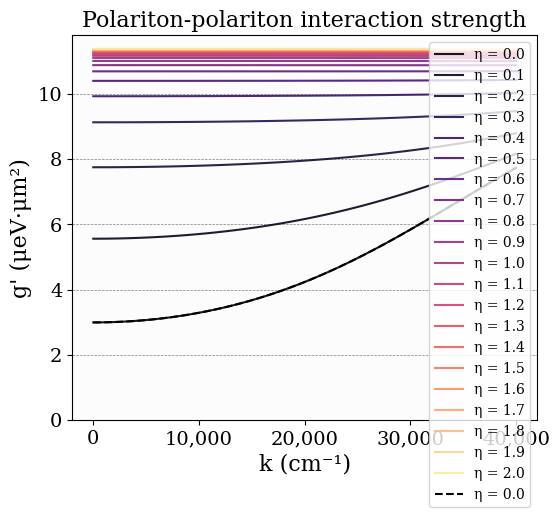

In [ ]:
# Interaction strength vs k for different eta — disorder-tuned vs disorder-free
L_terms_k_scan = 100
k_upper_k_scan = 1e8
n_k_k_scan = 100_000

g_k_results_dt = np.zeros((len(eta_grid), len(k_grid_disp)), dtype=float)
g_k_results_df = np.zeros((len(eta_grid), len(k_grid_disp)), dtype=float)

for eta_idx, eta_val in enumerate(eta_grid):
    for results_arr, dt in [(g_k_results_dt, True), (g_k_results_df, False)]:
        results_arr[eta_idx, :] = np.real(
            polariton_interaction_strength(
                eta_val, k_grid_disp,
                beta_value=beta, bare=False,
                L_terms=L_terms_k_scan,
                k_upper=k_upper_k_scan,
                n_k=n_k_k_scan,
                disorder_tuned=dt,
            )
        )

g_k_results_dt_plot = 1e18 * g_k_results_dt
g_k_results_df_plot = 1e18 * g_k_results_df

#region Screened polariton interaction strength vs k — paired
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12)

fig1, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig1.suptitle('Screened polariton interaction strength vs k')

for eta_idx in range(len(eta_grid)):
    clr = plt.cm.magma(eta_idx / len(eta_grid))
    lbl = f'η = {eta_grid[eta_idx]}'
    ax1.plot(0.01 * k_grid_disp, g_k_results_dt_plot[eta_idx], label=lbl, color=clr, alpha=0.9)
    ax2.plot(0.01 * k_grid_disp, g_k_results_df_plot[eta_idx], label=lbl, color=clr, alpha=0.9)

ax1.plot(0.01 * k_grid_disp, g_k_results_dt_plot[0], ls='--', color='black', label='η = 0.0')
ax2.plot(0.01 * k_grid_disp, g_k_results_df_plot[0], ls='--', color='black', label='η = 0.0')

for ax, title in [(ax1, 'Disorder-tuned cavity'), (ax2, 'Disorder-free cavity')]:
    ax.set_xlabel('k (cm⁻¹)')
    ax.set_ylabel("g' (μeV·μm²)")
    ax.set_title(title)
    ax.set_ylim(0, None)
    ax.legend()
    ax.xaxis.set_ticks(np.linspace(0, 40_000, 5))
    ax.set_xticklabels(['{:,}'.format(int(x)) for x in ax.get_xticks().tolist()])
    ax.grid(visible=True, which='both', axis='y', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_facecolor('0.99')

plt.tight_layout()
plt.show()
#endregion


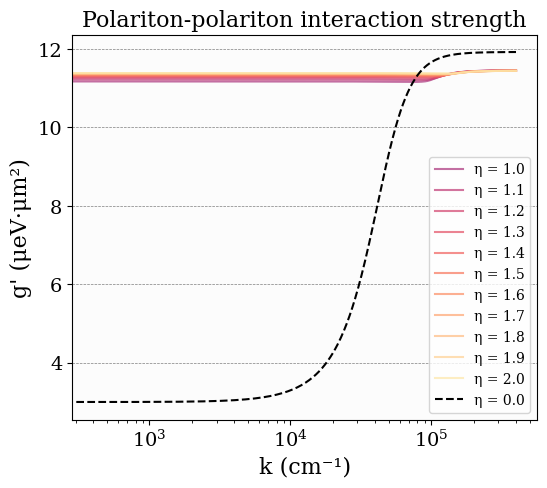

In [ ]:
# Interaction strength vs k on big-k grid — disorder-tuned vs disorder-free
L_terms_log_scan = 100
k_upper_log_scan = 1e8
n_k_log_scan = 100_000

N_k_log = 1000
k_grid_log = np.linspace(0, 4e7, N_k_log)

g_k_results_log_dt = np.zeros((len(eta_grid), len(k_grid_log)), dtype=float)
g_k_results_log_df = np.zeros((len(eta_grid), len(k_grid_log)), dtype=float)

for eta_idx, eta_val in enumerate(eta_grid):
    for results_arr, dt in [(g_k_results_log_dt, True), (g_k_results_log_df, False)]:
        results_arr[eta_idx, :] = np.real(
            polariton_interaction_strength(
                eta_val, k_grid_log,
                beta_value=beta, bare=False,
                L_terms=L_terms_log_scan,
                k_upper=k_upper_log_scan,
                n_k=n_k_log_scan,
                disorder_tuned=dt,
            )
        )

g_k_results_log_dt_plot = 1e18 * g_k_results_log_dt
g_k_results_log_df_plot = 1e18 * g_k_results_log_df

#region Screened interaction strength vs k — log scale, large k range, paired
plt.rc('legend', fontsize=10)
plt.rc('figure', titlesize=12)

fig2, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
fig2.suptitle('Screened polariton interaction strength vs k (log scale)')

for eta_idx in range(10, len(eta_grid)):
    clr = plt.cm.magma(eta_idx / len(eta_grid))
    lbl = f'η = {eta_grid[eta_idx]}'
    ax1.plot(0.01 * k_grid_log, g_k_results_log_dt_plot[eta_idx], label=lbl, color=clr, alpha=0.7)
    ax2.plot(0.01 * k_grid_log, g_k_results_log_df_plot[eta_idx], label=lbl, color=clr, alpha=0.7)

ax1.plot(0.01 * k_grid_log, g_k_results_log_dt_plot[0], ls='--', color='black', label='η = 0.0')
ax2.plot(0.01 * k_grid_log, g_k_results_log_df_plot[0], ls='--', color='black', label='η = 0.0')

for ax, title in [(ax1, 'Disorder-tuned cavity'), (ax2, 'Disorder-free cavity')]:
    ax.set_xlabel('k (cm⁻¹)')
    ax.set_ylabel("g' (μeV·μm²)")
    ax.set_title(title)
    ax.legend()
    ax.set_xscale('log')
    ax.grid(visible=True, which='both', axis='y', color='black', linestyle='--', linewidth=0.5, alpha=0.5)
    ax.set_facecolor('0.99')

plt.tight_layout()
plt.show()
#endregion


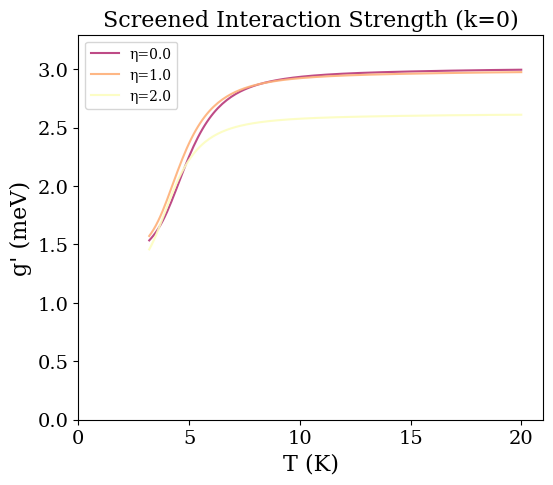

In [ ]:
# # Relative interaction strength vs temperature — disorder-tuned vs disorder-free
# L_terms_temp_scan = 10_000
# k_upper_mu = 1e8
# n_k_mu = 100_000

# T_range = np.linspace(3.2, 20.0, 169)
# beta_range = 1.0 / (k_B * T_range)
# eta_values_temp = [0.0, 1.0, 2.0]

# g_relative_dt = np.zeros((len(beta_range), len(eta_values_temp)), dtype=float)
# g_relative_df = np.zeros((len(beta_range), len(eta_values_temp)), dtype=float)
# g_screened_dt = np.zeros((len(beta_range), len(eta_values_temp)), dtype=float)
# g_screened_df = np.zeros((len(beta_range), len(eta_values_temp)), dtype=float)

# for temp_idx, beta_val in enumerate(beta_range):
#     for eta_idx, eta_val in enumerate(eta_values_temp):
#         for g_rel, g_scr, dt in [(g_relative_dt, g_screened_dt, True),
#                                   (g_relative_df, g_screened_df, False)]:
#             g_s = np.real(polariton_interaction_strength(
#                 eta_val, k_grid_disp, beta_value=beta_val, bare=False,
#                 L_terms=L_terms_temp_scan, k_upper=k_upper_mu, n_k=n_k_mu,
#                 disorder_tuned=dt,
#             ))
#             g_b = np.real(polariton_interaction_strength(
#                 eta_val, k_grid_disp, beta_value=beta_val, bare=True,
#                 L_terms=L_terms_temp_scan, k_upper=k_upper_mu, n_k=n_k_mu,
#                 disorder_tuned=dt,
#             ))
#             g_rel[temp_idx, eta_idx] = g_s[0] / g_b[0] if np.abs(g_b[0]) > 0 else np.nan
#             g_scr[temp_idx, eta_idx] = g_s[0]

# #region Relative screening strength vs temperature — paired
# plt.rc('legend', fontsize=10)
# plt.rc('figure', titlesize=12)

# fig3, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# fig3.suptitle("Relative Screening Strength g'/g  (k=0)")

# for eta_idx, eta_val in enumerate(eta_values_temp):
#     clr = plt.cm.magma(0.5 + eta_idx / max(1, len(eta_values_temp)))
#     lbl = f'η={eta_val}'
#     ax1.plot(T_range, g_relative_dt[:, eta_idx], label=lbl, color=clr, alpha=0.9)
#     ax2.plot(T_range, g_relative_df[:, eta_idx], label=lbl, color=clr, alpha=0.9)

# for ax, title in [(ax1, 'Disorder-tuned cavity'), (ax2, 'Disorder-free cavity')]:
#     ax.set_xlabel('T (K)')
#     ax.set_ylabel("g'/g")
#     ax.set_title(title)
#     ax.axhline(1.0, color='gray', linestyle='--', linewidth=1)
#     ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
#     ax.set_ylim(0, 1.05)
#     ax.set_xlim(0, 21)
#     ax.legend()

# plt.tight_layout()
# plt.show()
# #endregion

# #region Screened interaction strength vs temperature — paired
# g_screened_dt_plot = 1e18 * g_screened_dt
# g_screened_df_plot = 1e18 * g_screened_df

# fig4, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5), sharey=True)
# fig4.suptitle("Screened Interaction Strength g'  (k=0)")

# for eta_idx, eta_val in enumerate(eta_values_temp):
#     clr = plt.cm.magma(0.5 + eta_idx / max(1, len(eta_values_temp)))
#     lbl = f'η={eta_val}'
#     ax1.plot(T_range, g_screened_dt_plot[:, eta_idx], label=lbl, color=clr, alpha=0.9)
#     ax2.plot(T_range, g_screened_df_plot[:, eta_idx], label=lbl, color=clr, alpha=0.9)

# g_max = max(np.nanmax(g_screened_dt_plot), np.nanmax(g_screened_df_plot))
# for ax, title in [(ax1, 'Disorder-tuned cavity'), (ax2, 'Disorder-free cavity')]:
#     ax.set_xlabel('T (K)')
#     ax.set_ylabel("g' (μeV·μm²)")
#     ax.set_title(title)
#     ax.set_ylim(0, g_max * 1.1)
#     ax.set_xlim(0, 21)
#     ax.legend()

# plt.tight_layout()
# plt.show()
# #endregion
